In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df=pd.read_csv(r'C:\Users\yaswa\OneDrive\Desktop\artificial intelligence project\data\final_processed_data.csv')

In [32]:
bowler_stats = df.groupby('Bowler_Name').agg({
    'run': 'sum',
    'isWicket': 'sum',
    'oversActual': 'count'
}).reset_index()

In [33]:
bowler_stats['overs_bowled'] = bowler_stats['oversActual'] / 6
bowler_stats['economy'] = bowler_stats['run'] / bowler_stats['overs_bowled']
bowler_stats['strike_rate'] = bowler_stats['oversActual'] / bowler_stats['isWicket']
bowler_stats = bowler_stats.fillna(0)
bowler_stats.sort_values('economy').head()

,Bowler_Name,run,isWicket,oversActual,overs_bowled,economy,strike_rate
88,DS Airee,6,1,12,2.000000,3.000000,12.000000
155,KS Williamson,3,0,6,1.000000,3.000000,inf
231,OEG Baartman,48,5,74,12.333333,3.891892,14.800000
50,BJ Currie,16,2,24,4.000000,4.000000,12.000000
219,NL McCullum,21,3,31,5.166667,4.064516,10.333333


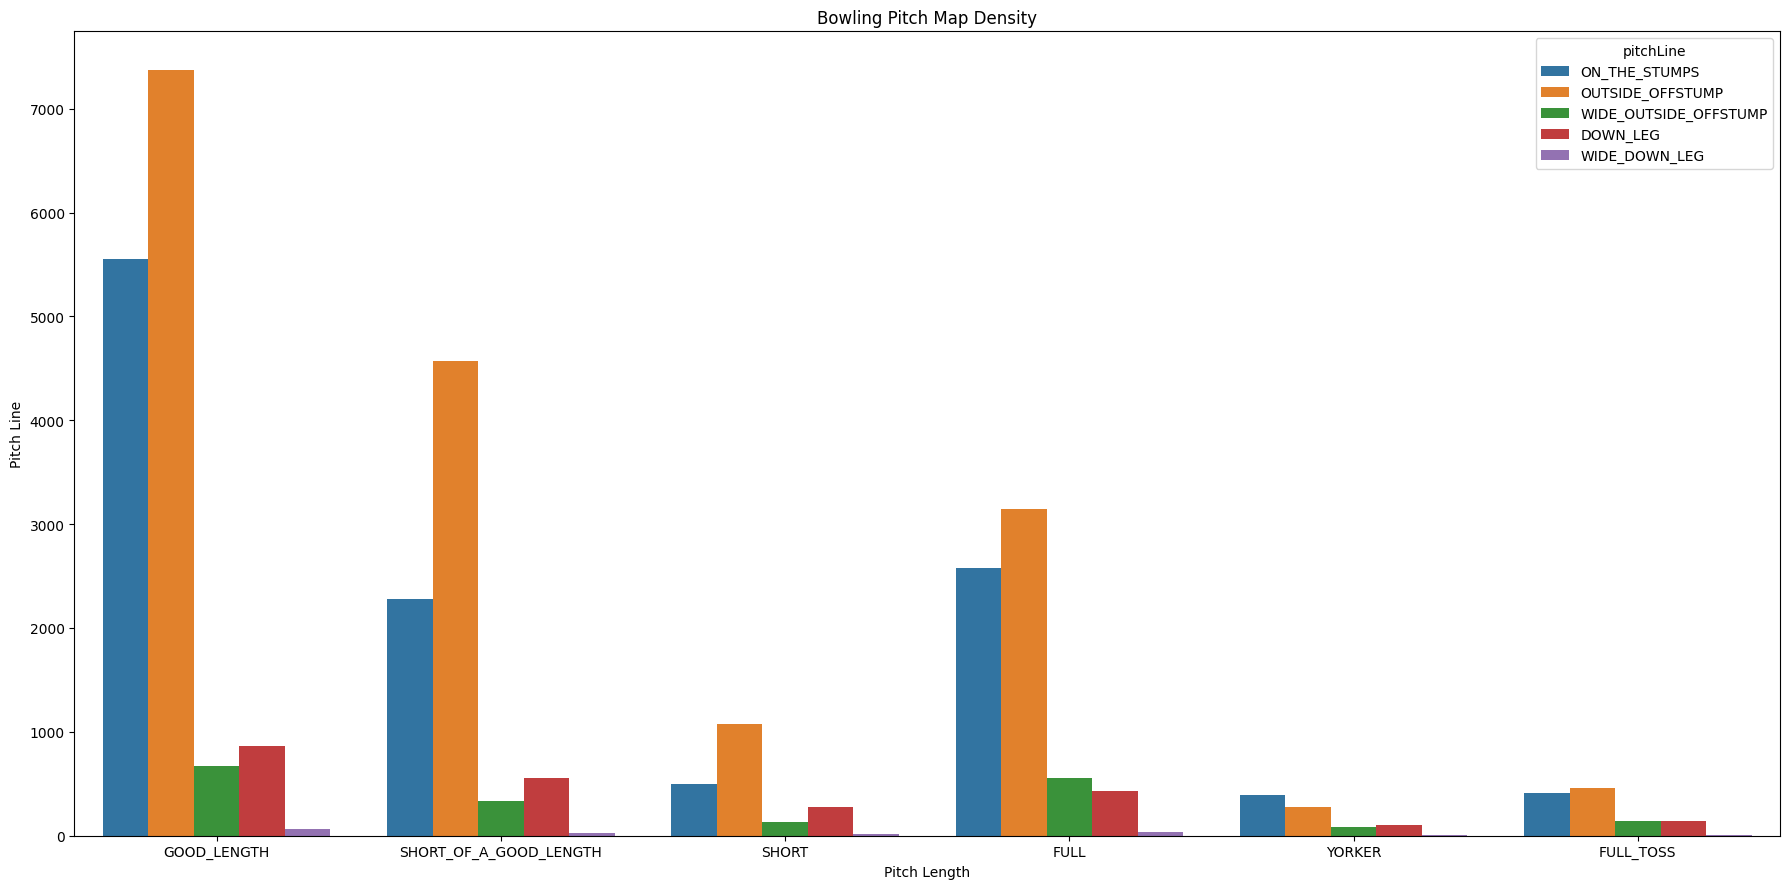

In [34]:
plt.figure(figsize=(18,9))
sns.countplot(
    data=df,
    x='pitchLength', hue='pitchLine'
)
plt.title('Bowling Pitch Map Density')
plt.xlabel('Pitch Length')
plt.ylabel('Pitch Line')
plt.tight_layout()
plt.show()

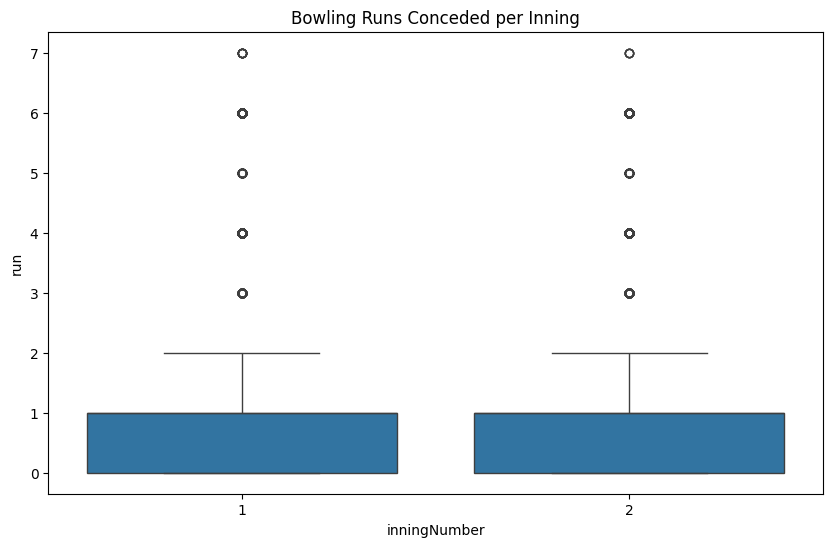

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='inningNumber', y='run')
plt.title('Bowling Runs Conceded per Inning')
plt.show()

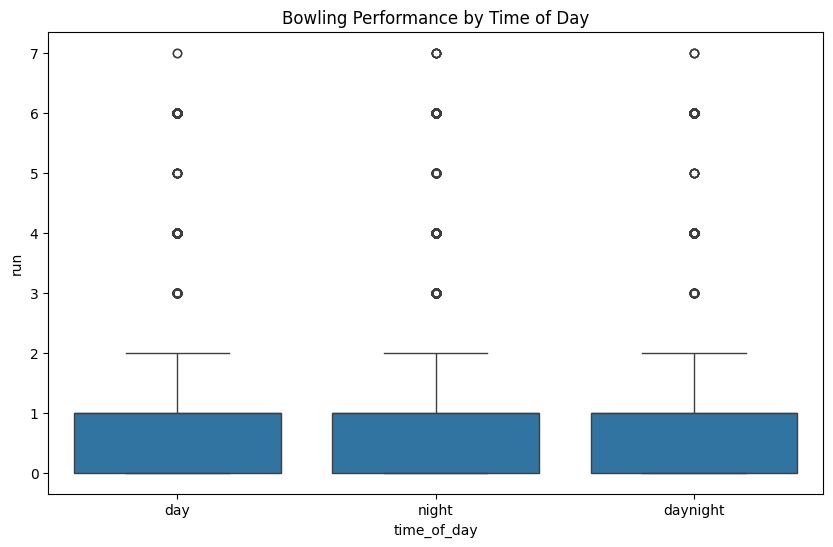

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='time_of_day', y='run')
plt.title('Bowling Performance by Time of Day')
plt.show()

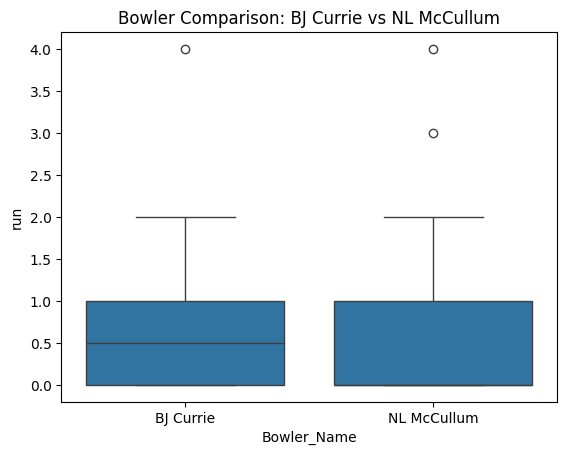

In [37]:
def compare_bowlers(bowler1, bowler2):
    df1 = df[df['Bowler_Name'].isin([bowler1, bowler2])]
    sns.boxplot(data=df1, x='Bowler_Name', y='run')
    plt.title(f'Bowler Comparison: {bowler1} vs {bowler2}')
    plt.show()

compare_bowlers('BJ Currie', 'NL McCullum')

In [38]:
bat_bowl = df.groupby(['Batsman_Name', 'Bowler_Name']).agg({
    'run': 'sum',
    'isWicket': 'sum',
    'isFour': 'sum',
    'isSix': 'sum'
}).reset_index()

bat_bowl.sort_values('run', ascending=False).head(10)

,Batsman_Name,Bowler_Name,run,isWicket,isFour,isSix
2472,JC Buttler,MA Starc,47,0,5,3
2486,JC Buttler,PVD Chameera,45,0,4,2
3070,KS Williamson,MA Starc,44,0,7,1
4038,MR Marsh,MJ Santner,44,0,2,4
3744,MJ Guptill,AC Evans,42,0,3,3
3859,MN Samuels,CJ Jordan,41,0,7,0
2496,JC Buttler,TA Boult,40,0,4,1
5200,Q de Kock,Taskin Ahmed,39,0,3,3
2450,JC Buttler,CBRLS Kumara,38,0,3,2
2460,JC Buttler,IS Sodhi,37,1,3,2


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# features = ['pitchLine', 'pitchLength', 'inningNumber', 'time_of_day','Bowler_Name']
# X = pd.get_dummies(df[features])
# y = df['run']

# # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# # model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
# # model.fit(X_train, y_train)
# print("Accuracy:", model.score(X_test, y_test))

In [40]:
# y_pred=model.predict(X_test)
# accuracy_score(y_test,y_pred)

In [41]:
# classification_report(y_test,y_pred)

In [42]:
# cm = confusion_matrix(y_test, y_pred)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix - Wicket Prediction")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


In [43]:
df['isBoundary'] = ((df['isFour'] == 1) | (df['isSix'] == 1)).astype(int)

In [44]:
df.columns

Index(['Unnamed: 0', 'match_obj_id', 'inningNumber', 'oversActual',
       'pitchLine', 'pitchLength', 'isFour', 'isSix', 'isWicket', 'byes',
       'legbyes', 'wides', 'noballs', 'run', 'totalRuns', 'totalWickets',
       'shotType', 'time_of_day', 'Ground Name', 'Batsman_Name',
       'Batsman_Role', 'Full Name', 'Batsman_Batting_Style',
       'Batsman_Playing_Role', 'Bowler_Name', 'Bowler_Role',
       'Full Name_bowler', 'Batting Style (s)_bowler', 'Bowler_Bowling_Style',
       'Bowler_Playing_Role', 'isBoundary'],
      dtype='object')

In [45]:
features = ['pitchLine', 'pitchLength','shotType','Batsman_Batting_Style','Bowler_Bowling_Style']
X = pd.get_dummies(df[features], drop_first=True)
y = df['isBoundary']

In [46]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# model = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
# model.fit(X_train, y_train)

In [48]:
# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:, 1]

In [49]:
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [50]:
# plt.figure(figsize=(6,5))
# sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix - Boundary Prediction")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [51]:
# compare_df = X_test.copy()
# compare_df['Actual_Boundary'] = y_test.values
# compare_df['Predicted_Boundary'] = y_pred
# compare_df['Boundary_Probability'] = y_prob
# compare_df.head(10)

In [52]:
# importances = pd.Series(model.feature_importances_, index=X.columns)
# importances.sort_values().plot(kind='barh', figsize=(8,12))
# plt.title("Feature Importance - Boundary Probability Model")
# plt.tight_layout()
# plt.show()


In [53]:
# classification_report(y_test,y_pred)

In [54]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [57]:
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\yaswa\OneDrive\Desktop\python practice\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [59]:
history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7849 - loss: 0.5135 - val_accuracy: 0.8619 - val_loss: 0.4054
Epoch 2/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.4033 - val_accuracy: 0.8619 - val_loss: 0.3787
Epoch 3/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8707 - loss: 0.3849 - val_accuracy: 0.8619 - val_loss: 0.3644
Epoch 4/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8704 - loss: 0.3765 - val_accuracy: 0.8619 - val_loss: 0.3570
Epoch 5/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8699 - loss: 0.3656 - val_accuracy: 0.8619 - val_loss: 0.3526
Epoch 6/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8705 - loss: 0.3645 - val_accuracy: 0.8621 - val_loss: 0.3521
Epoch 7/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8695 - loss: 0.3579 - val_accuracy: 0.8617 - val_loss: 0.3497
Epoch 8/40
331/331 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8705 - loss: 0.3578 - val_accuracy: 0.

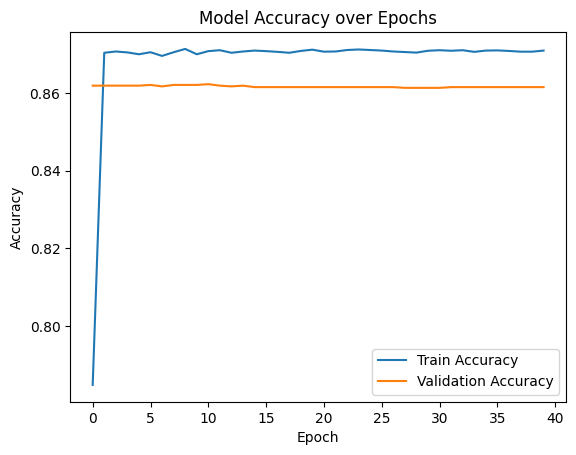

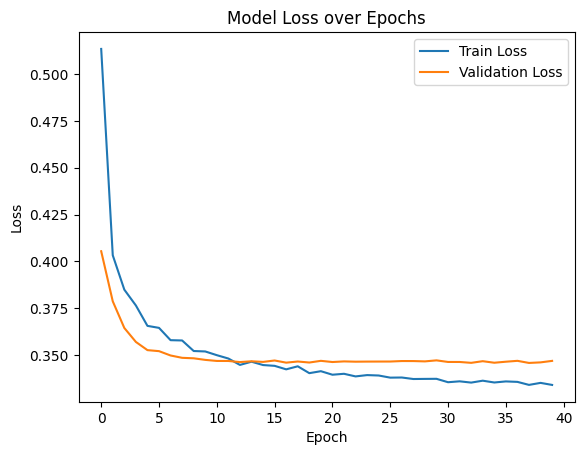

In [60]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [61]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5742
           1       0.25      0.00      0.00       864

    accuracy                           0.87      6606
   macro avg       0.56      0.50      0.47      6606
weighted avg       0.79      0.87      0.81      6606

[[5739    3]
 [ 863    1]]


In [62]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


In [66]:
from tensorflow.keras.layers import BatchNormalization
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

c:\Users\yaswa\OneDrive\Desktop\python practice\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
          class_weight=class_weights)


Epoch 1/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6011 - loss: 0.6436 - val_accuracy: 0.5805 - val_loss: 0.6223
Epoch 2/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5989 - loss: 0.5986 - val_accuracy: 0.5665 - val_loss: 0.6220
Epoch 3/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5937 - loss: 0.5814 - val_accuracy: 0.5975 - val_loss: 0.5869
Epoch 4/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5969 - loss: 0.5778 - val_accuracy: 0.5919 - val_loss: 0.6049
Epoch 5/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6004 - loss: 0.5723 - val_accuracy: 0.5593 - val_loss: 0.6241
Epoch 6/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5990 - loss: 0.5699 - val_accuracy: 0.5830 - val_loss: 0.5968
Epoch 7/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5940 - loss: 0.5700 - val_accuracy: 0.5970 - val_loss: 0.5968
Epoch 8/50
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5992 - loss: 0.5692 - val_accuracy: 0.

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step


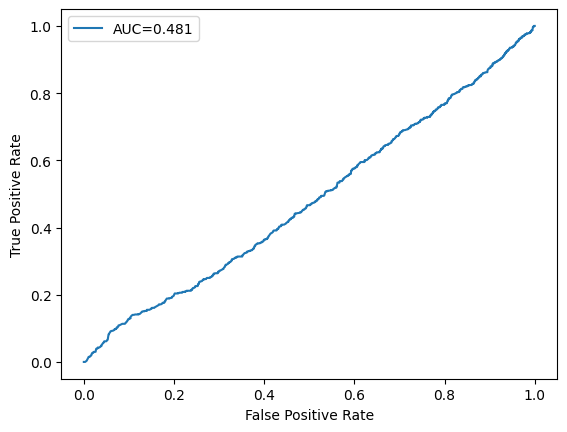

In [65]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = model.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


 model is prepared and trained in predict_boundary.ipynb